# Compare Vabamorf with homonyms dataset


## Table of contents

1. [**Gathering Data**](#andmete_kogumine)
2. [**Evaluation (BertMorphTaggerV2 vs Vabamorf)**](#hindamine_v2)
3. [**Results BertMorphTaggerV2 vs Vabamorf**](#tulemused_v2)
4. [**Evaluation BertMorphTaggerHomonyms vs Vabamorf**](#hindamine_homonyms)
5. [**Results BertMorphTaggerHomonyms vs Vabamorf**](#tulemused_homonyms)
6. [**Results Baselines**](#tulemused_baseline)

[end](#end)


In [1]:
print("Test")

Test


In [2]:
from pathlib import Path
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

import os
import json
import warnings
import types
import evaluate
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

# from bert_morph_tagger_notebook_functions import NotebookFunctions

# from simpletransformers.ner import NERModel, NERArgs
from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from estnltk.converters.label_studio.labelling_configurations import (
    PhraseClassificationConfiguration,
)
from estnltk.converters.label_studio.labelling_tasks import PhraseClassificationTask

In [3]:
poseval = evaluate.load("evaluate-metric/poseval", module_type="metric")


def custom_metrics(preds, labels):

    # Evaluate using poseval
    result = poseval.compute(predictions=preds, references=labels)

    return result

<a id='andmete_kogumine'></a>


### Gathering data


In [4]:
# Use specific annotation configurations that were used in homonyms dataset
annotation_confs = {
    1: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    16: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    17: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g", "sg p": "sg p"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g - ainsuse omastav, sg p - ainsuse osastav):",
        header_placement="middle",
    ),
    19: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg g": "sg g", "sg p": "sg p", "adt": "adt"},
        header="Vali sõna morfoloogiline vorm (sg g - ainsuse omastav, sg p - ainsuse osastav, adt - lühike sisseütlev):",
        header_placement="middle",
    ),
}

In [ ]:
# Collect input files
input_files = []
input_dir = "../data/homonymous_word_forms/annotations/"
for fname in os.listdir(input_dir):
    if os.path.isdir(os.path.join(input_dir, fname)):
        for subfname in os.listdir(os.path.join(input_dir, fname)):
            if subfname.endswith(".json"):
                inflection_type = int(subfname.split("_")[2])  # infl_type_xx_1000_vx...
                input_files.append(
                    (
                        inflection_type,
                        "../data/homonymous_word_forms/annotations/"
                        + fname
                        + "/"
                        + subfname,
                    )
                )

if not input_files:
    raise RuntimeError("No input files found!")

print(f"Found {len(input_files)} input files.")

Found 8 input files.


In [ ]:
overall_data = []
# Extract data from input files
for infl_type, input_file in input_files:
    print(f"Processing file: {input_file} (inflection type {infl_type})")
    num = input_file.split("/")[3]
    annotation_conf = annotation_confs[infl_type]
    with open(input_file, "r", encoding="utf-8") as f:
        raw = f.read()
    task = PhraseClassificationTask(
        annotation_conf,
        input_layer="morph",
        output_layer="morph",
        label_attribute="label",
    )
    classified_sentences = task.import_data(raw)

    # Create dataframe from classified sentences
    data = []
    for sentence in classified_sentences:
        for annotation in sentence.morph:
            if (
                "class_label" in sentence.meta
                and sentence.meta["class_label"] is not None
            ):
                data.append(
                    {
                        "num": num,
                        "inflection_type": infl_type,
                        "sentence": sentence.text,
                        "word": annotation.text,
                        "word_span": (annotation.start, annotation.end),
                        "label": sentence.meta["class_label"],
                    }
                )
    df = pd.DataFrame(data)
    output_csv = f"../data/homonymous_word_forms/processed/homonyms_infltype_{num}_{infl_type}.csv"
    df.to_csv(output_csv, index=False)
    print(f"Saved processed data to {output_csv}")
    overall_data.extend(data)

# Create overall dataframe
overall_df = pd.DataFrame(overall_data)
overall_output_csv = "../data/homonymous_word_forms/processed/homonyms_overall.csv"
overall_df.to_csv(overall_output_csv, index=False)
print(f"Saved overall processed data to {overall_output_csv}")

Processing file: ./homonymous_word_forms/annotations/1/infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json (inflection type 1)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_1.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_16_1000_v1_project-2-at-2024-11-21-19-27-9e8ae0c2.json (inflection type 16)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_16.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_17_1000_v1.json (inflection type 17)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_17.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_19_1000_v1_project-6-at-2025-11-15-14-13-42753676.json (inflection type 19)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_19.csv
Processing file: ./homonymous_word_forms/annotations/2/infl_type_01_1000_v2_project-5-at-2024-12-11-21-53-280753b4.json (inflection type 

<a id='hindamineV2'></a>


### Evaluation (BertMorphTaggerV2 vs Vabamorf)


In [ ]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2/"
bmt_model = BertMorphTagger(model_location=bmt_model_name)

# Load default resolver
resolver = make_resolver()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 863.93it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [17]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")

In [14]:
overall_df.groupby(["inflection_type", "label"]).size().reset_index().sort_values(
    by="inflection_type"
)

,inflection_type,label,0
0,1,['sg g'],1232
1,1,['sg n'],764
2,16,['sg g'],1080
3,16,['sg n'],890
4,17,['sg g'],524
5,17,['sg n'],791
6,17,['sg p'],609
7,19,['adt'],94
8,19,['sg g'],1621
9,19,['sg p'],281


In [8]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",[sg n]
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",[sg n]
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",[sg n]
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",[sg n]
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",[sg g]


In [ ]:
outer = tqdm(
    overall_df.iterrows(),
    total=len(overall_df),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = (
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results.csv"
)
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTagger vs Vabamorf:  18%|█▊        | 1454/7886 [01:52<06:56, 15.44it/s]e:\Git_projects\EstNLTK\morf_yhestaja\bert_tokens_to_words_rewriter.py:154: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': 'sg g', 'partofspeech': 'S', 'probability': 0.63123}]).
  warnings.warn(f"(!) No matching {words_layer.name} span for bert token {bert_tokens_layer[i]}.")
Evaluating BertMorphTagger vs Vabamorf:  35%|███▌      | 2769/7886 [03:24<06:00, 14.19it/s]e:\Git_projects\EstNLTK\morf_yhestaja\bert_tokens_to_words_rewriter.py:154: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': '?', 'partofspeech': '', 'probability': 0.94938}]).
  warnings.warn(f"(!) No matching {words_layer.name} span for bert token {bert_tokens_layer[i]}.")
Evaluating BertMorphTagger vs Vabamorf:  43%|████▎     | 3403/7886 [04:12<04:51, 15.37it/s]e:\Git_projects\EstNLTK\morf_yhestaja\bert_tokens_to_words_rewriter.py:154: Use

<a id='tulemused_v2'></a>


### Results BertMorphTaggerV2 vs Vabamorf


In [14]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

# # flat lists (one label per sentence)
# preds = results_df["bmt_prediction"].tolist()
# refs = results_df["true_label"].tolist()

# # convert to list-of-lists where each inner list is the token sequence for one sentence
# preds_grouped = [[p] for p in preds]
# refs_grouped = [[r] for r in refs]

# # sanity checks
# assert len(preds_grouped) == len(refs_grouped)
# for p, r in zip(preds_grouped, refs_grouped):
#     assert len(p) == len(r)  # should be 1 for your case

# # Call poseval
# results = poseval.compute(predictions=preds_grouped, references=refs_grouped)
# # Print weighted average metrics as percentages
# print(f"Accuracy: \t{results['accuracy']:.2%}")
# print(f"Precision: \t{results['weighted avg']['precision']:.2%}")
# print(f"Recall: \t{results['weighted avg']['recall']:.2%}")
# print(f"F1-score: \t{results['weighted avg']['f1-score']:.2%}")

In [4]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

            ?       0.00      0.00      0.00         0
          adt       0.66      0.35      0.46        94
           da       0.00      0.00      0.00         0
           ge       0.00      0.00      0.00         0
           ma       0.00      0.00      0.00         0
           me       0.00      0.00      0.00         0
        neg o       0.00      0.00      0.00         0
no_prediction       0.00      0.00      0.00         0
            o       0.00      0.00      0.00         0
         pl g       0.00      0.00      0.00         0
         pl n       0.00      0.00      0.00         0
         pl p       0.00      0.00      0.00         0
            s       0.00      0.00      0.00         0
       sg all       0.00      0.00      0.00         0
        sg el       0.00      0.00      0.00         0
        sg es       0.00      0.00      0.00        

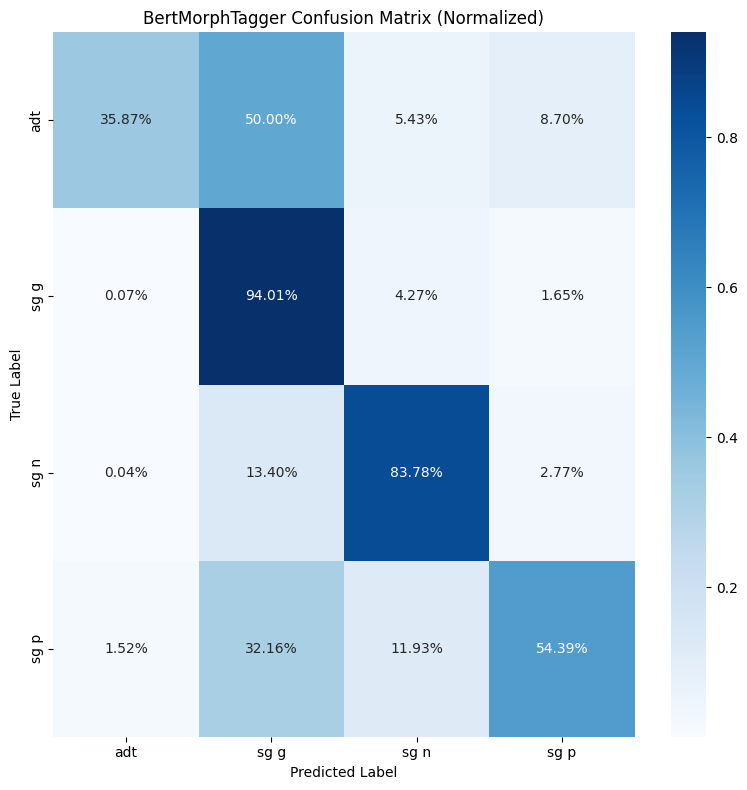

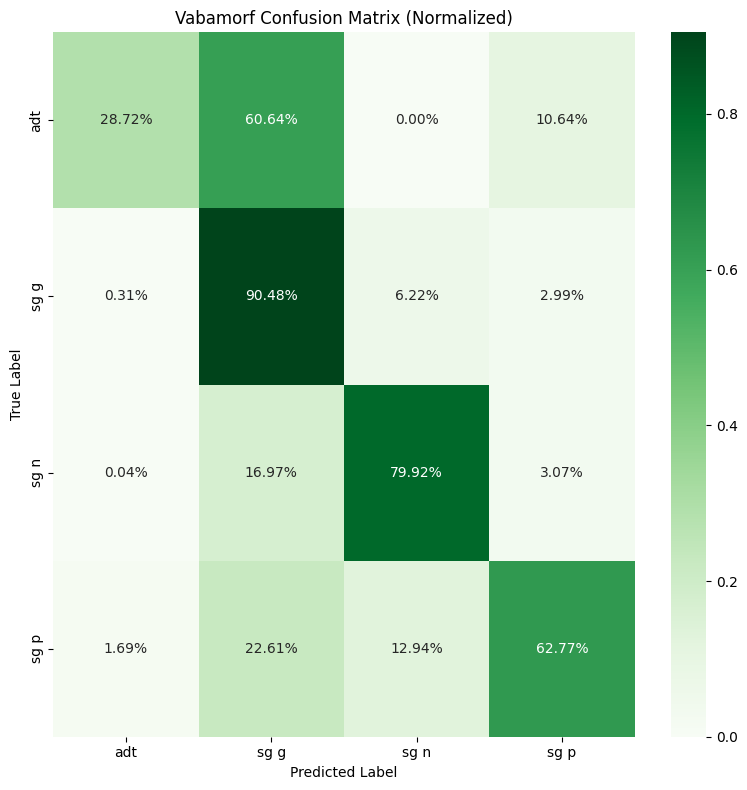

In [5]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/v2/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/v2/VabamorfCM", dpi=300)
plt.show()

In [7]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

            ?       0.00      0.00      0.00         0
          adt       0.00      0.00      0.00         0
           ge       0.00      0.00      0.00         0
no_prediction       0.00      0.00      0.00         0
         pl g       0.00      0.00      0.00         0
         pl p       0.00      0.00      0.00         0
       sg all       0.00      0.00      0.00         0
        sg es       0.00      0.00      0.00         0
         sg g       0.91      0.90      0.90      1232
        sg in       0.00      0.00      0.00         0
       sg kom       0.00      0.00      0.00         0
         sg n       0.87      0.83      0.85       764
         sg p       0.00      0.00      0.00         0

     accuracy                           0.87      1996
    macro avg       0.14      0.13      0.13      1996
 weighted avg       0.90      0.87      0.88 

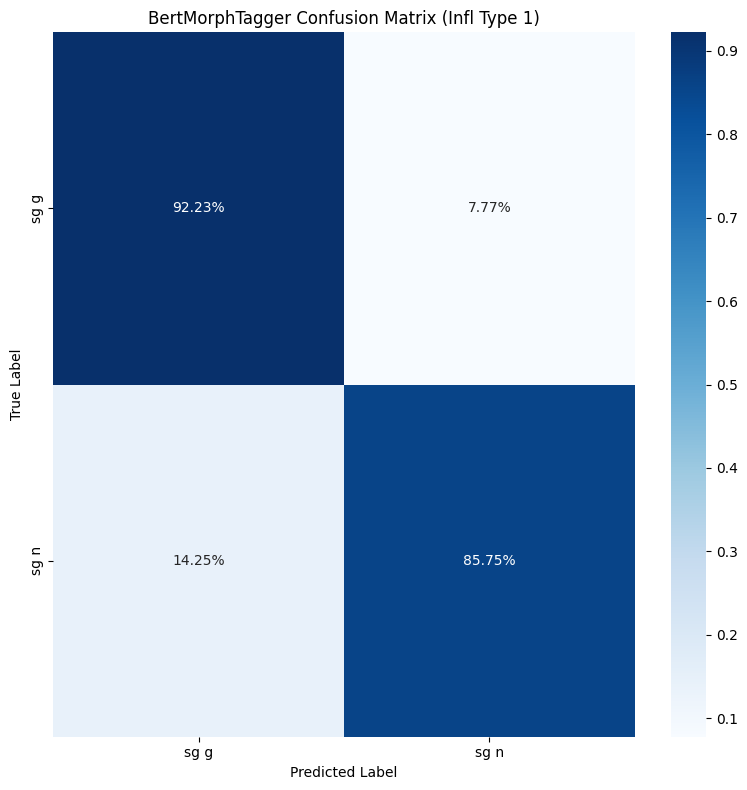

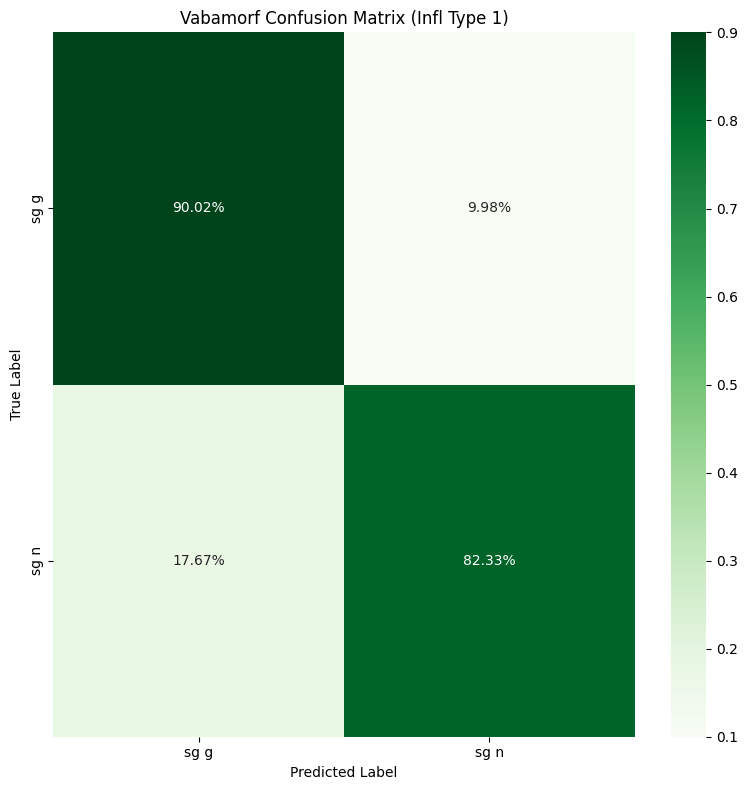

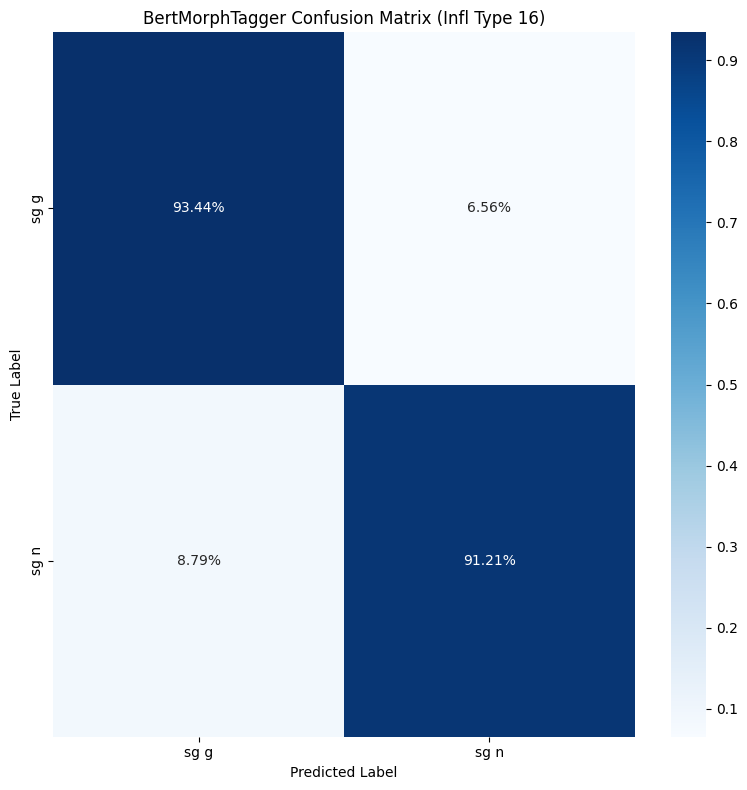

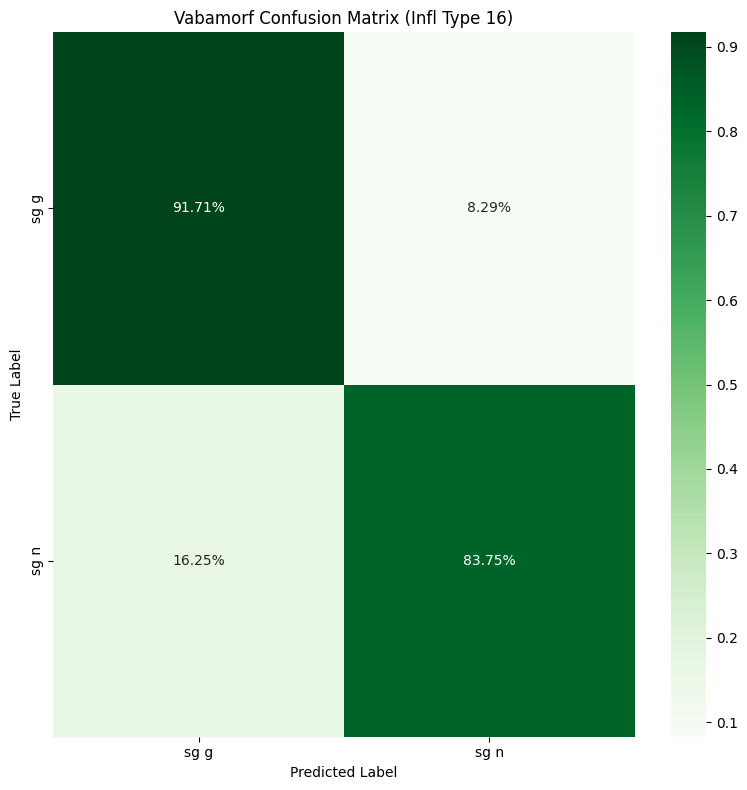

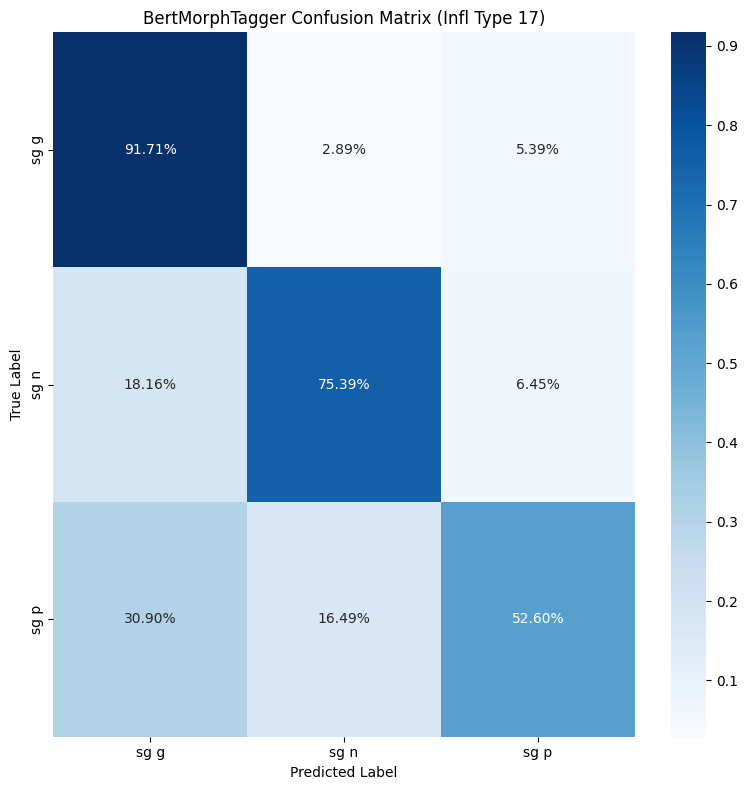

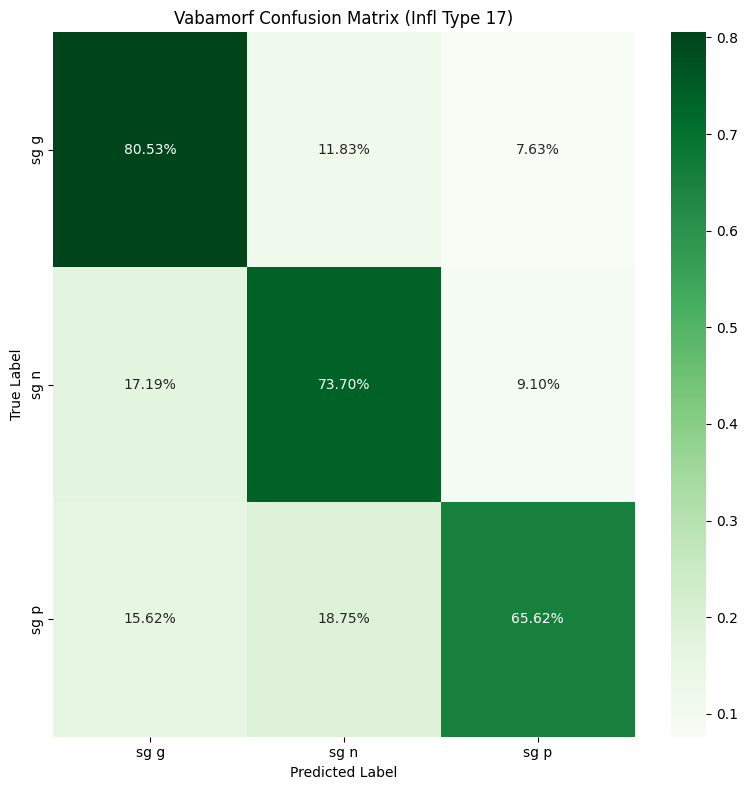

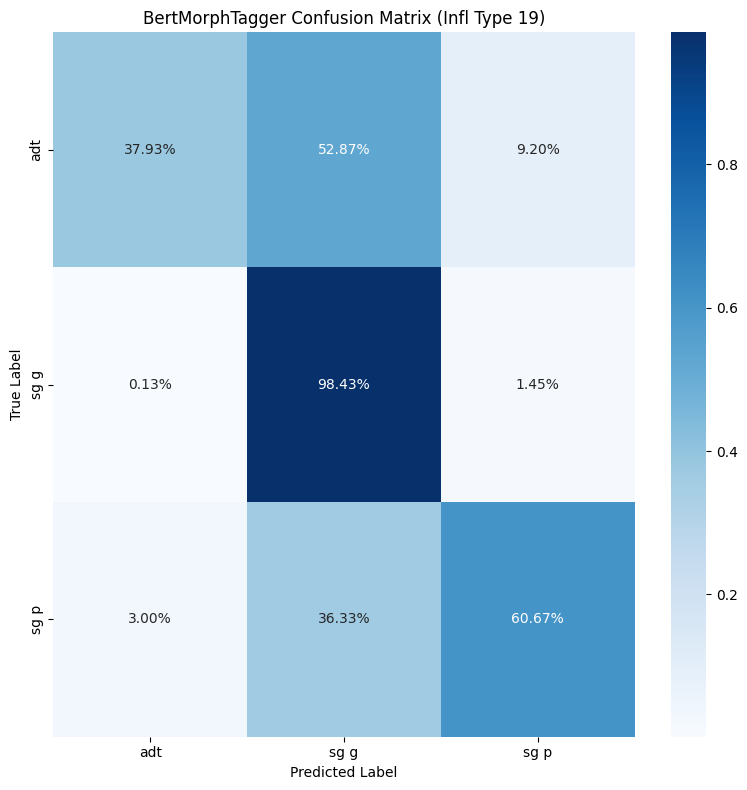

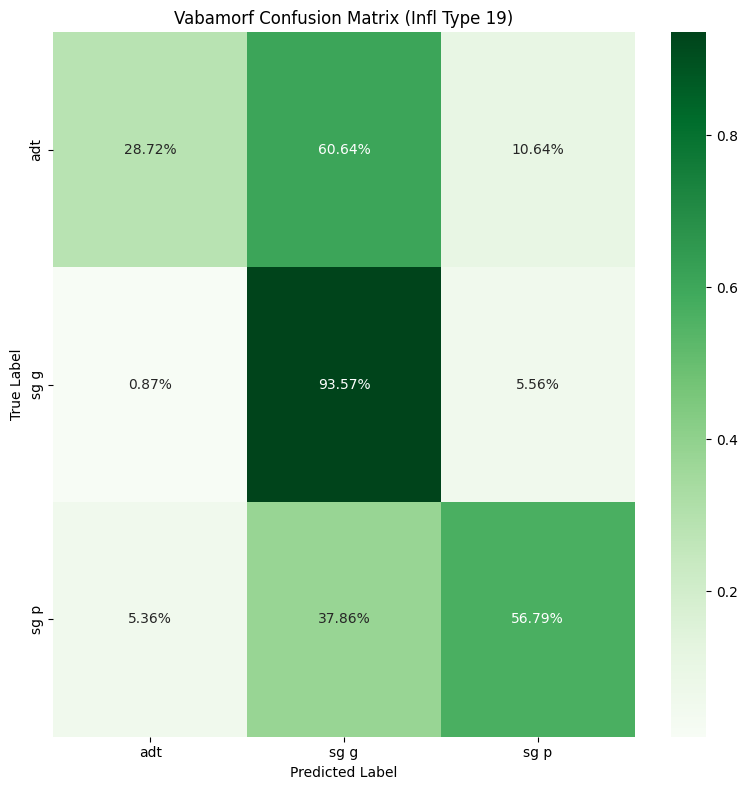

In [9]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/v2/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300)
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/v2/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

<a id='hindamine_homonyms'></a>


### Evaluation (BertMorphTaggerHomonyms vs Vabamorf)


In [22]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2_homonym/"
bmt_model = BertMorphTagger(model_location=bmt_model_name)

# Load default resolver
resolver = make_resolver()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [23]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")

In [24]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n']
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n']
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n']
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n']
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g']


In [44]:
outer = tqdm(
    overall_df.iterrows(),
    total=len(overall_df),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = (
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_homonym.csv"
)
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTaggerHomonym vs Vabamorf:  18%|█▊        | 1454/7886 [01:56<07:22, 14.52it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:154: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': 'sg n', 'partofspeech': 'S', 'probability': 0.99995}]).
  warnings.warn(f"(!) No matching {words_layer.name} span for bert token {bert_tokens_layer[i]}.")
Evaluating BertMorphTaggerHomonym vs Vabamorf:  35%|███▌      | 2769/7886 [03:36<06:42, 12.72it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:154: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': 'sg n', 'partofspeech': 'S', 'probability': 0.99996}]).
  warnings.warn(f"(!) No matching {words_layer.name} span for bert token {bert_tokens_layer[i]}.")
Evaluating BertMorphTaggerHomonym vs Vabamorf:  43%|████▎     | 3402/7886 [04:29<05:09, 14.49it/s]E:\Git_p

<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerHomonym vs Vabamorf


In [10]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_homonym.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

In [11]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

         adt       1.00      1.00      1.00        94
        sg g       1.00      1.00      1.00      4457
        sg n       1.00      1.00      1.00      2445
        sg p       1.00      1.00      1.00       890

    accuracy                           1.00      7886
   macro avg       1.00      1.00      1.00      7886
weighted avg       1.00      1.00      1.00      7886

Vabamorf Classification Report:
              precision    recall  f1-score   support

         adt       0.47      0.29      0.36        94
           o       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.86      0.90      0.88      4457
        sg n       0.83      0.80      0.82      2445
        sg p       0.72      0.63      0.67       890

    accuracy                    

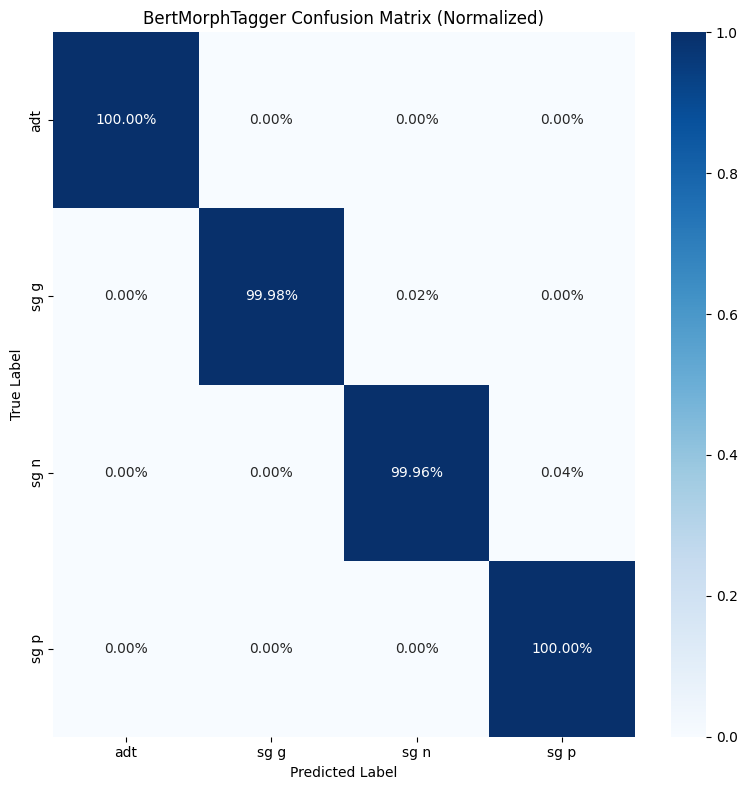

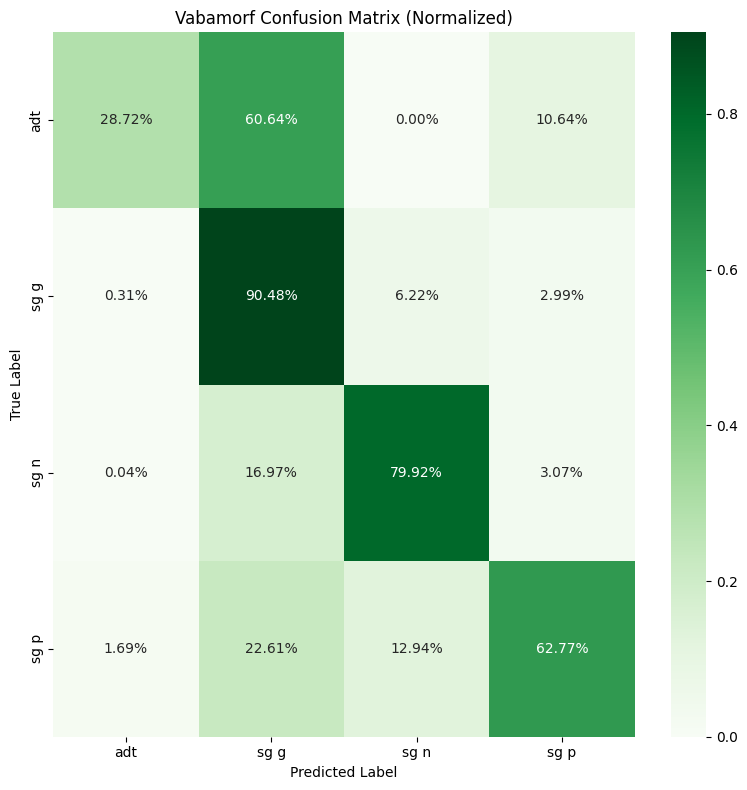

In [12]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym/VabamorfCM", dpi=300)
plt.show()

In [13]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764
        sg p       0.00      0.00      0.00         0

    accuracy                           1.00      1996
   macro avg       0.67      0.67      0.67      1996
weighted avg       1.00      1.00      1.00      1996

Vabamorf Classification Report:
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

========Inflection Type 16========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1080
    

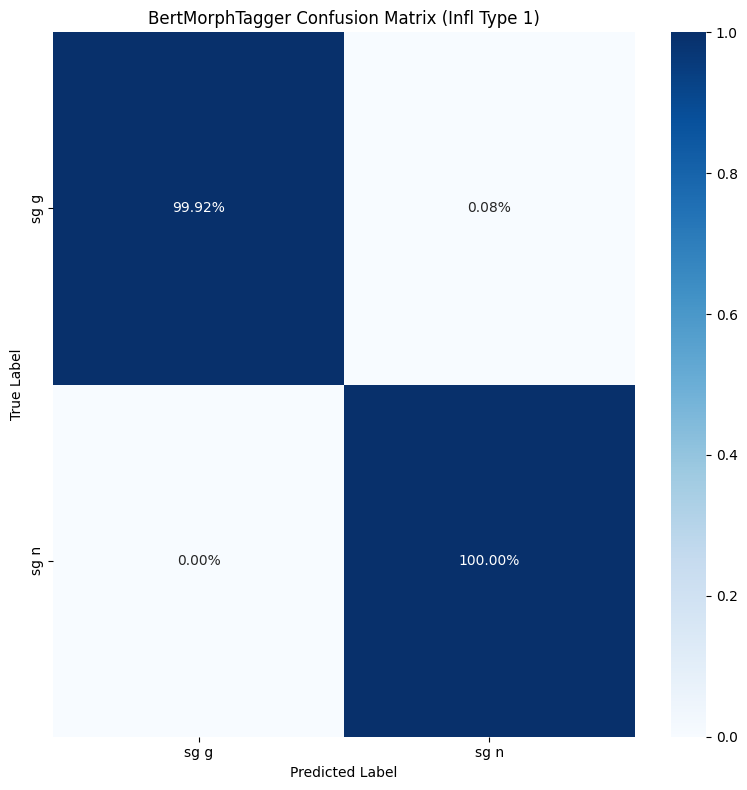

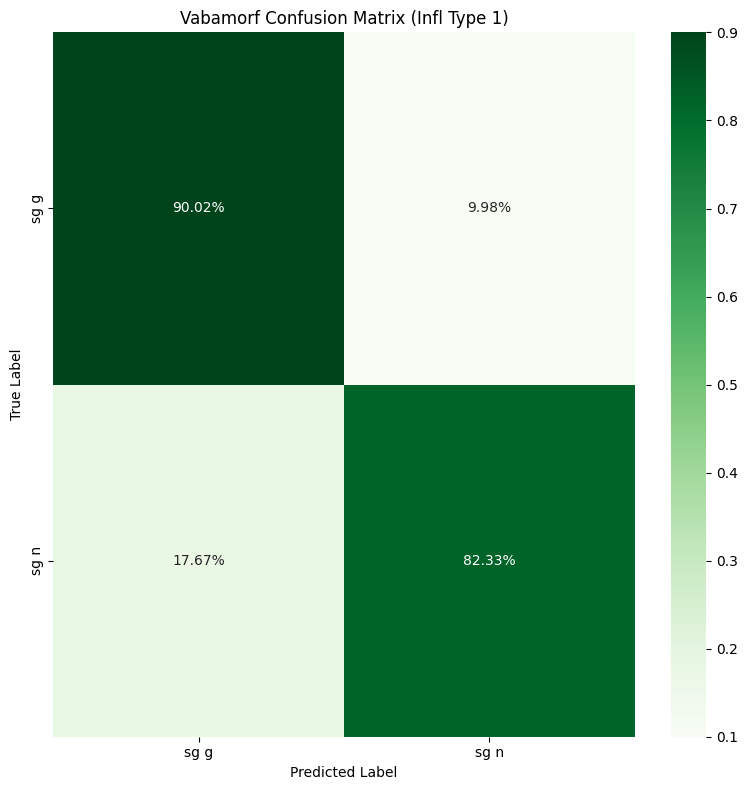

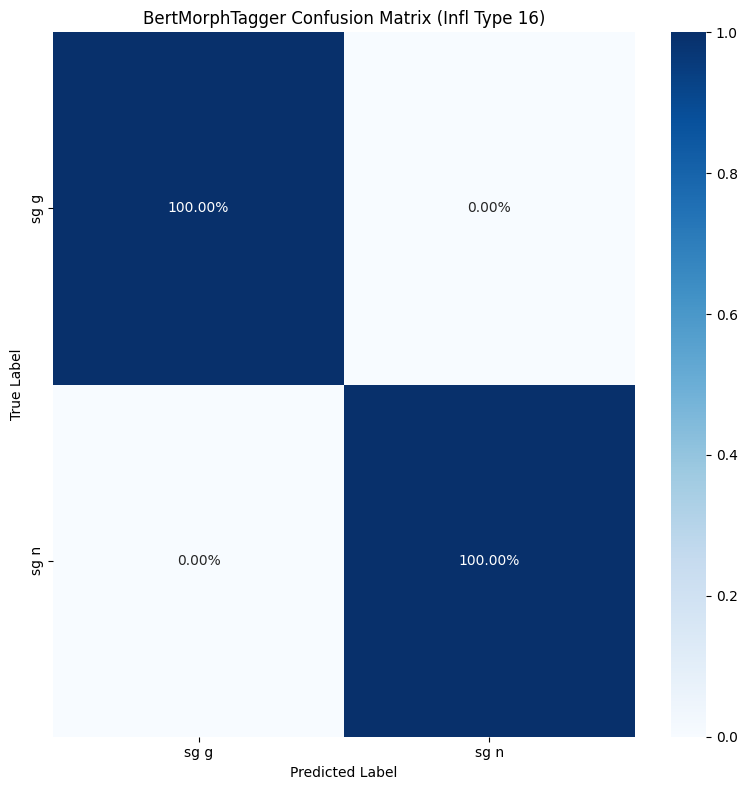

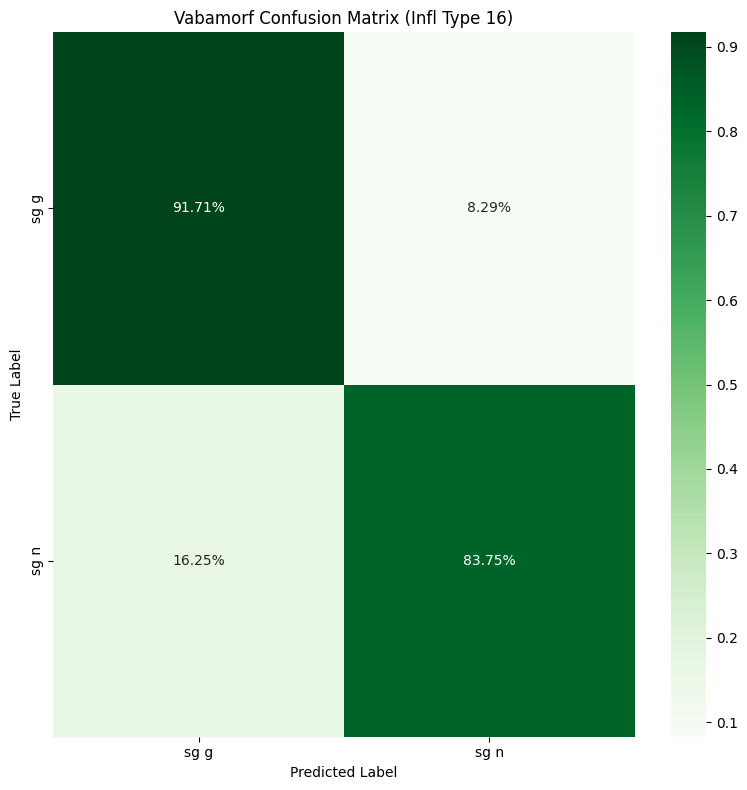

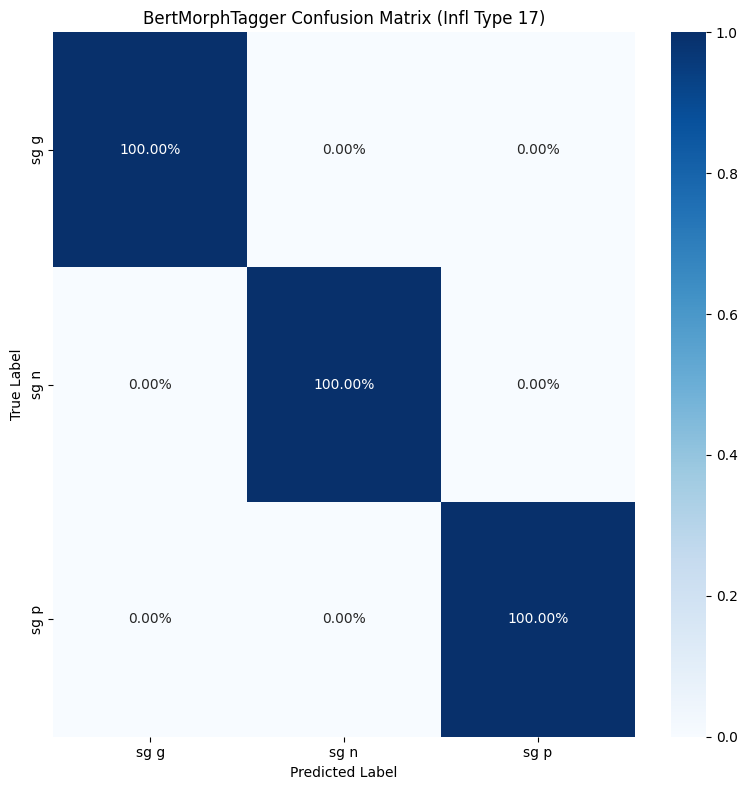

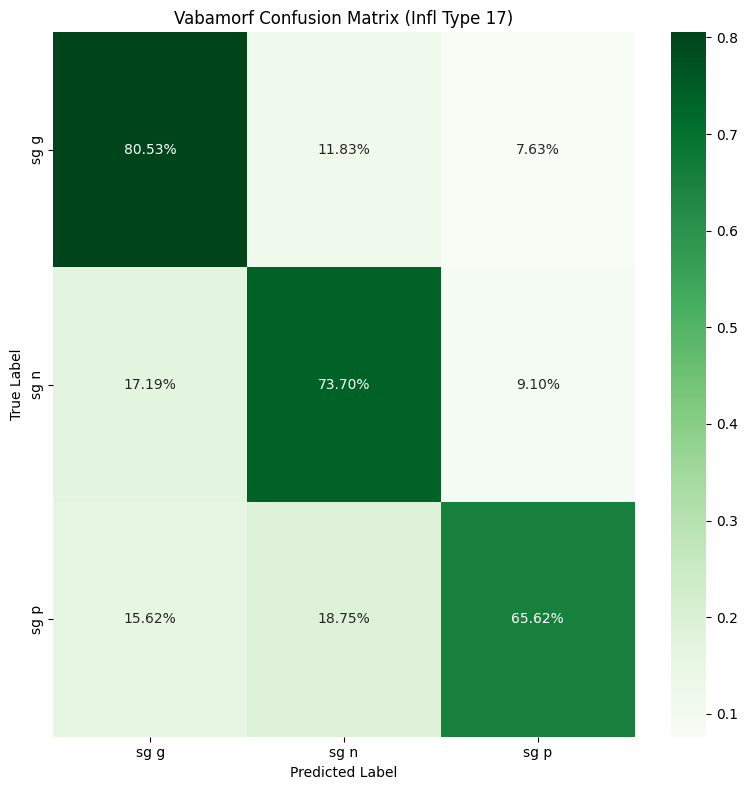

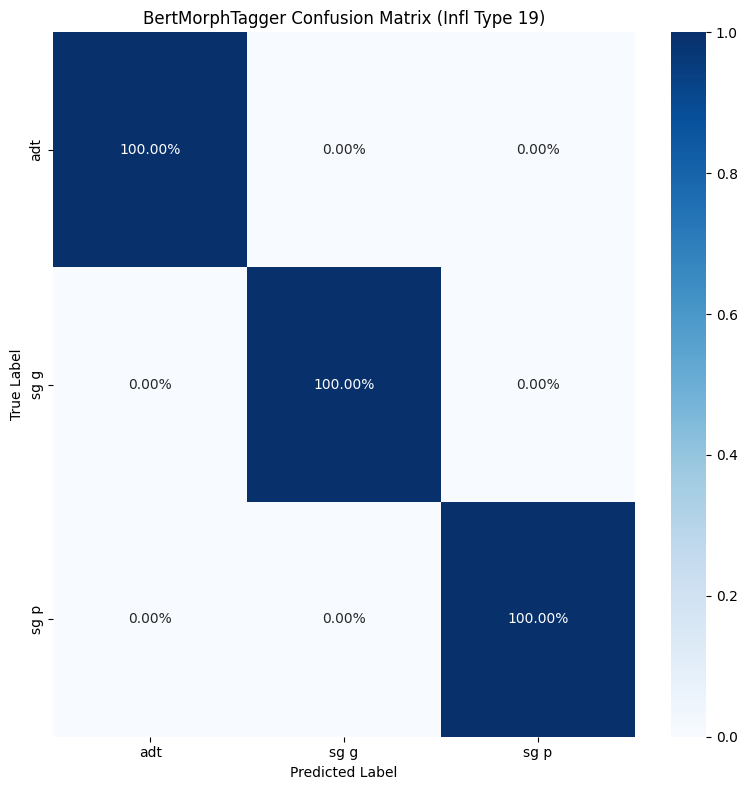

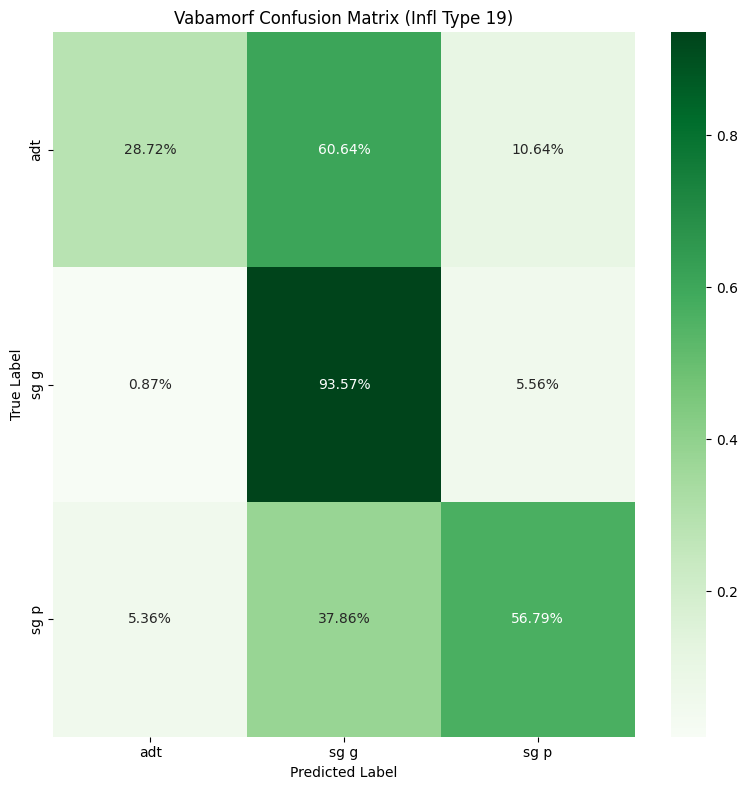

In [14]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/homonym/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300
    )
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/homonym/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

<a id='tulemused_baseline'></a>


### Baseline models (random choice and most frequent choice)


### Label distribution


In [15]:
# View label distribution in the dataset

# Count occurrences of each label in the entire dataset
label_distribution_overall = (
    results_df.groupby("true_label").size().reset_index(name="count")
)

# Calculate percentages
label_distribution_overall["percentage"] = label_distribution_overall["count"].apply(
    lambda x: round(x / label_distribution_overall["count"].sum() * 100, 3)
)
print("=" * 5, "Overall Label Distribution", "=" * 5)
print(label_distribution_overall, "\n")


# View label distribution per inflection type and add percentage columns
print("=" * 5, "Label Distribution per Inflection Type", "=" * 5)

# Count occurrences of each label per inflection type
label_distribution = (
    results_df.groupby(["inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)

# Calculate percentages
label_distribution["percentage"] = label_distribution.groupby("inflection_type")[
    "count"
].transform(lambda x: round(x / x.sum() * 100, 3))

# Separate dataframes per inflection type
label_distribution_dfs = {}
for infl_type in label_distribution["inflection_type"].unique():
    label_distribution_dfs[infl_type] = label_distribution[
        label_distribution["inflection_type"] == infl_type
    ].reset_index(drop=True)
    print(f"Inflection Type {infl_type} Label Distribution:")
    print(label_distribution_dfs[infl_type])

===== Overall Label Distribution =====
  true_label  count  percentage
0        adt     94       1.192
1       sg g   4457      56.518
2       sg n   2445      31.004
3       sg p    890      11.286 

===== Label Distribution per Inflection Type =====
Inflection Type 1 Label Distribution:
   inflection_type true_label  count  percentage
0                1       sg g   1232      61.723
1                1       sg n    764      38.277
Inflection Type 16 Label Distribution:
   inflection_type true_label  count  percentage
0               16       sg g   1080      54.822
1               16       sg n    890      45.178
Inflection Type 17 Label Distribution:
   inflection_type true_label  count  percentage
0               17       sg g    524      27.235
1               17       sg n    791      41.112
2               17       sg p    609      31.653
Inflection Type 19 Label Distribution:
   inflection_type true_label  count  percentage
0               19        adt     94       4.709
1    

#### Overall homonym dataset


In [15]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [16]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline.fit(
        results_df["true_label"],
        results_df["true_label"],
    )
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cr = sklearn.metrics.classification_report(
        y_true=results_df["true_label"],
        y_pred=baseline_predictions,
        zero_division=0,
    )
    print(f"{name} Classification Report:")
    print(baseline_cr)

Most Frequent Class Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00        94
        sg g       0.57      1.00      0.72      4457
        sg n       0.00      0.00      0.00      2445
        sg p       0.00      0.00      0.00       890

    accuracy                           0.57      7886
   macro avg       0.14      0.25      0.18      7886
weighted avg       0.32      0.57      0.41      7886

Random Choice Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.01      0.27      0.02        94
        sg g       0.55      0.25      0.34      4457
        sg n       0.31      0.25      0.28      2445
        sg p       0.11      0.25      0.16       890

    accuracy                           0.25      7886
   macro avg       0.25      0.25      0.20      7886
weighted avg       0.42      0.25      0.30      7886



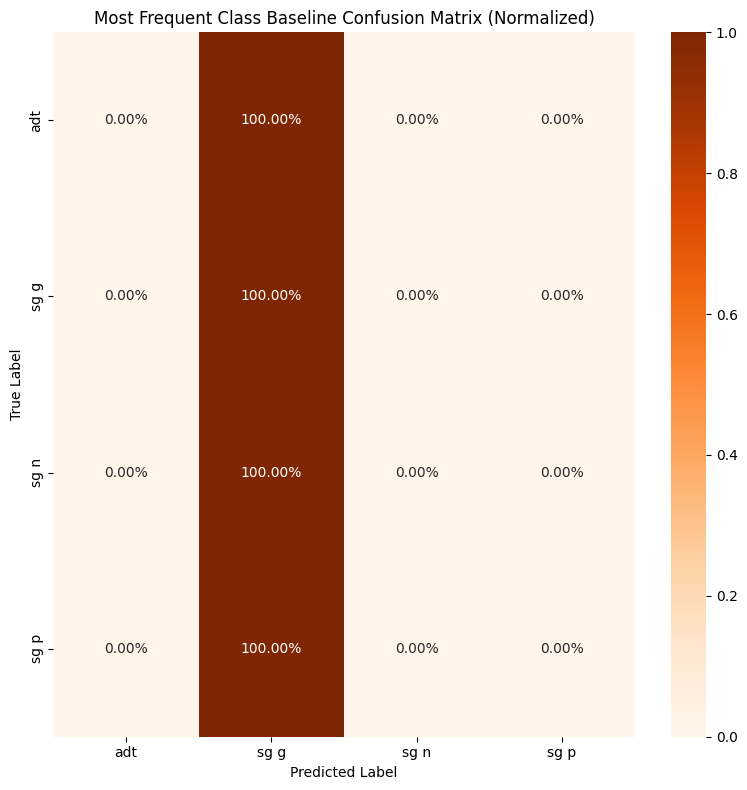

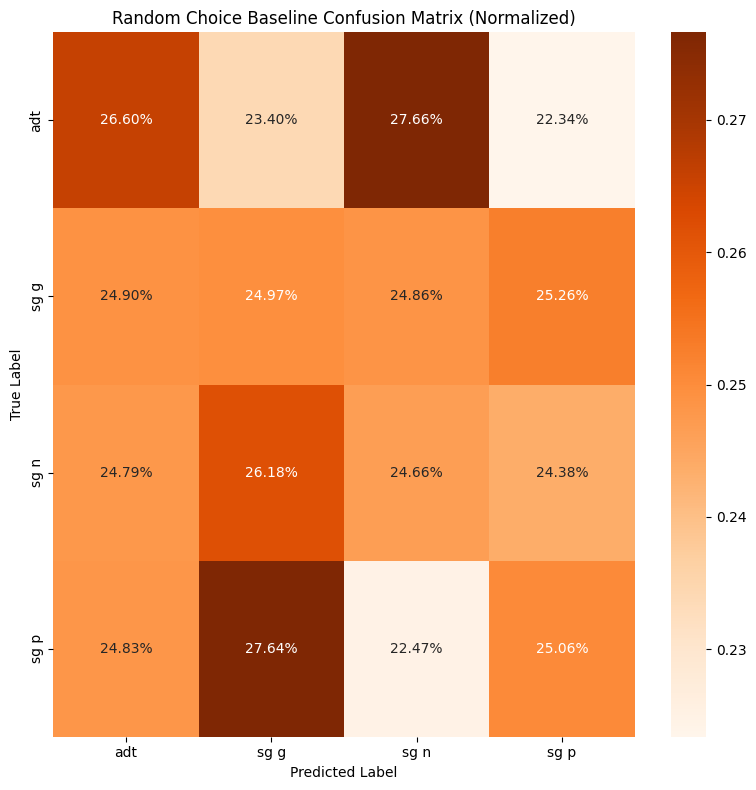

In [19]:
# Plot confusion matrices for overall results with baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cm = sklearn.metrics.confusion_matrix(
        y_true=results_df["true_label"], y_pred=baseline_predictions
    )
    baseline_cm_normalized = (
        baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
    )
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        baseline_cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Oranges",
        xticklabels=np.unique(results_df["true_label"]),
        yticklabels=np.unique(results_df["true_label"]),
    )
    plt.title(f"{name} Confusion Matrix (Normalized)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/baseline/homonym_ds/" + name.replace(" ", "") + "CM", dpi=300
    )
    plt.show()

#### Per inflection type homonym dataset


In [20]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [21]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline.fit(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cr = sklearn.metrics.classification_report(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
            zero_division=0,
        )
        print(f"{name} Classification Report for Inflection Type {inflection_type}:")
        print(baseline_cr)

Most Frequent Class Baseline Classification Report for Inflection Type 1:
              precision    recall  f1-score   support

        sg g       0.62      1.00      0.76      1232
        sg n       0.00      0.00      0.00       764

    accuracy                           0.62      1996
   macro avg       0.31      0.50      0.38      1996
weighted avg       0.38      0.62      0.47      1996

Most Frequent Class Baseline Classification Report for Inflection Type 16:
              precision    recall  f1-score   support

        sg g       0.55      1.00      0.71      1080
        sg n       0.00      0.00      0.00       890

    accuracy                           0.55      1970
   macro avg       0.27      0.50      0.35      1970
weighted avg       0.30      0.55      0.39      1970

Most Frequent Class Baseline Classification Report for Inflection Type 17:
              precision    recall  f1-score   support

        sg g       0.00      0.00      0.00       524
        sg n 

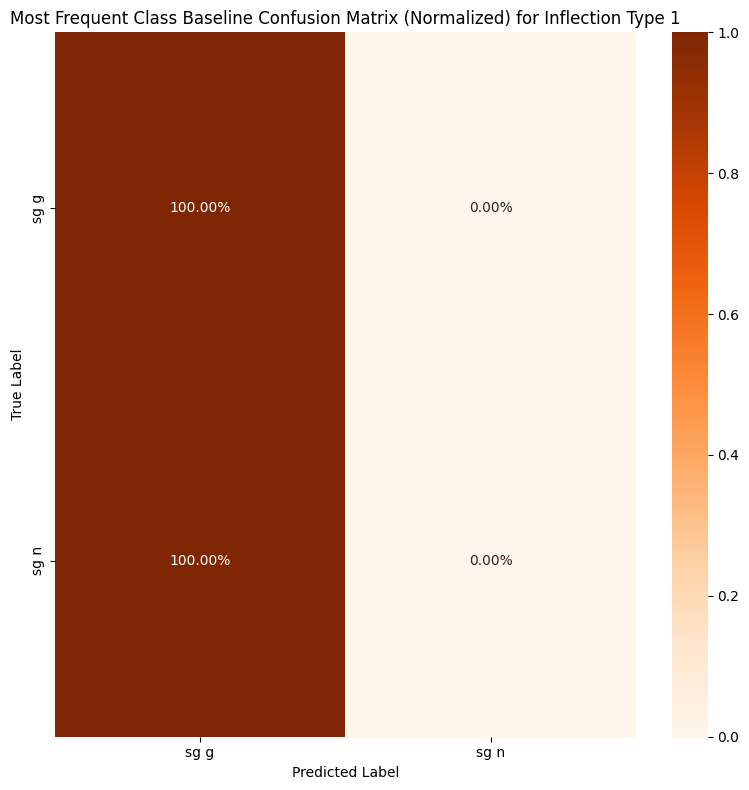

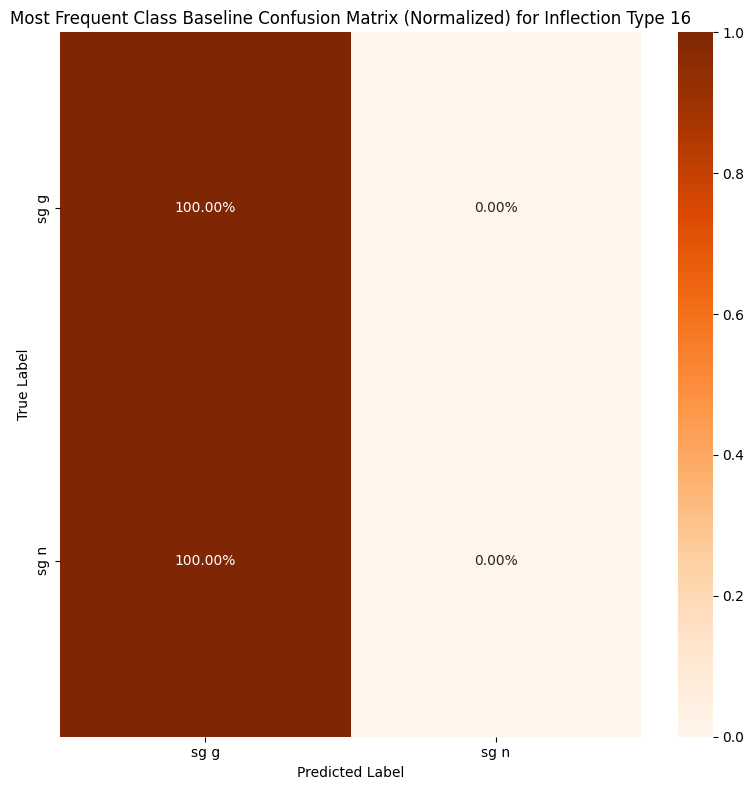

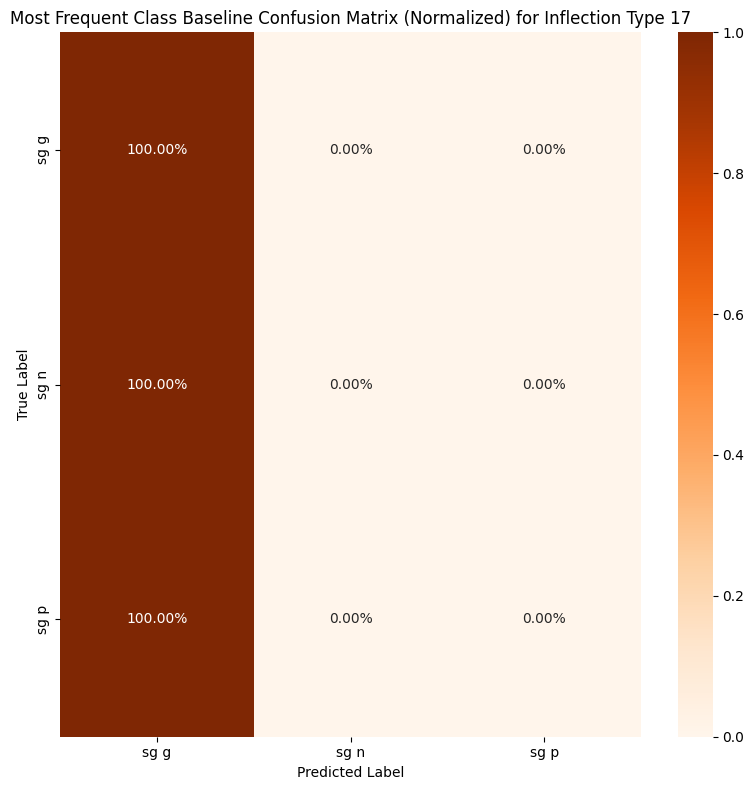

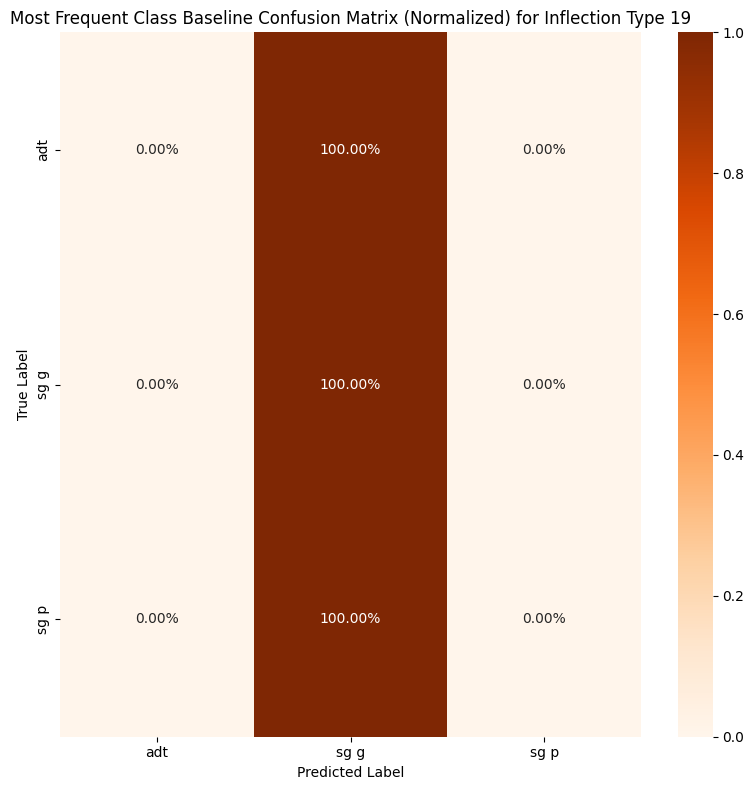

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


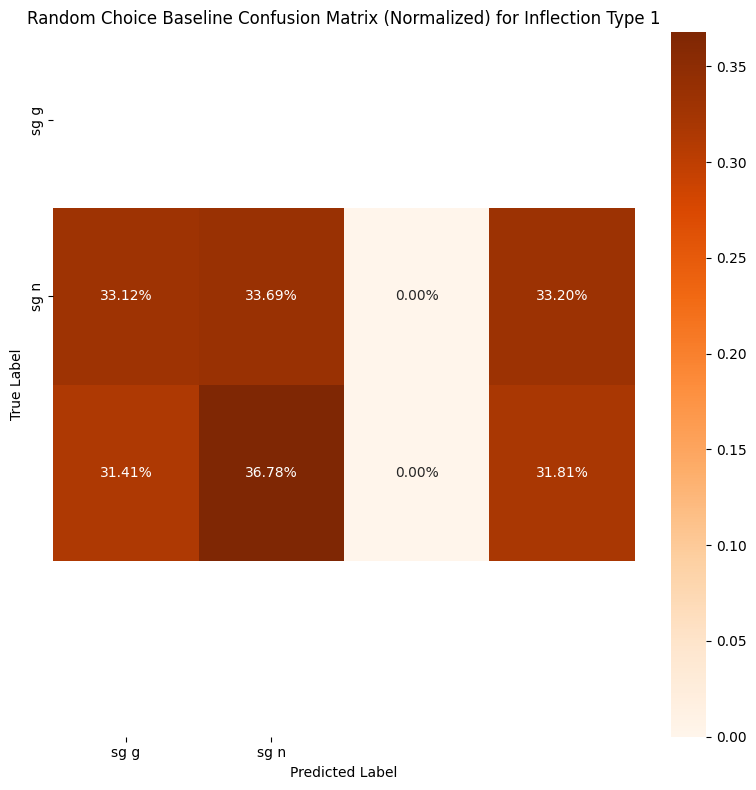

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


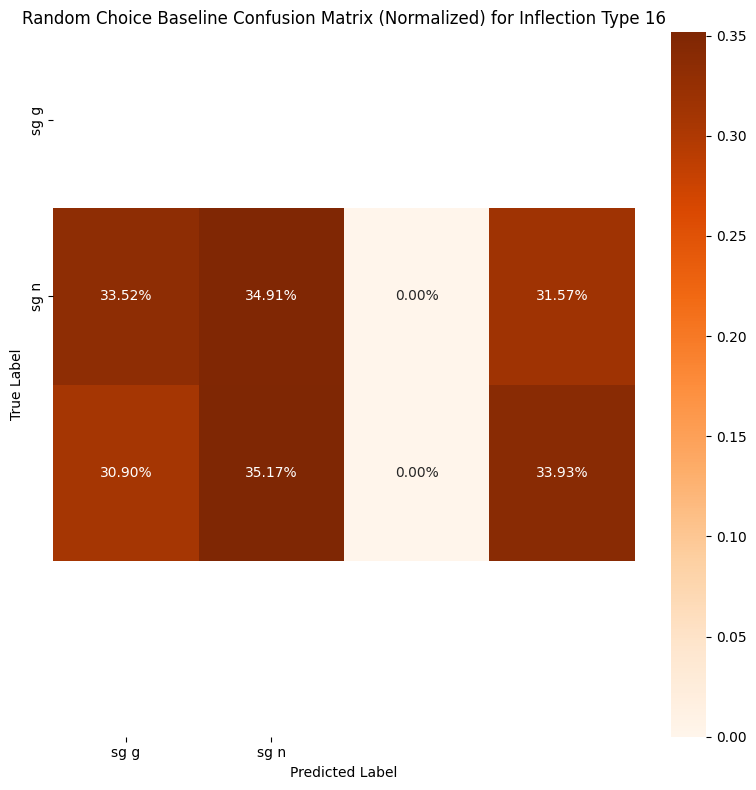

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


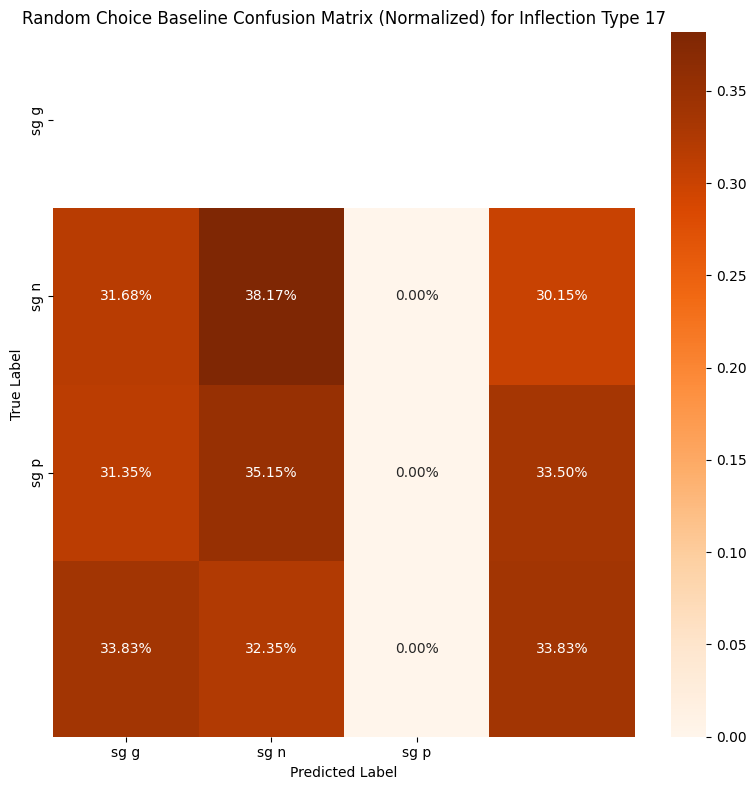

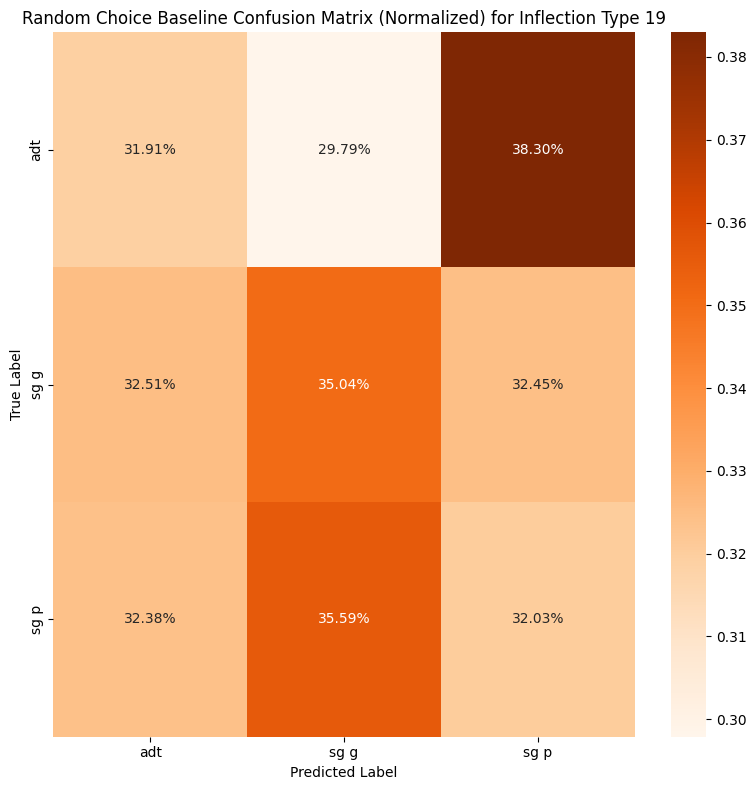

In [23]:
# Plot confusion matrices per inflection type for baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cm = sklearn.metrics.confusion_matrix(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
        )
        baseline_cm_normalized = (
            baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
        )
        plt.figure(figsize=(8, 8))
        sns.heatmap(
            baseline_cm_normalized,
            annot=True,
            fmt=".2%",
            cmap="Oranges",
            xticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
            yticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
        )
        plt.title(
            f"{name} Confusion Matrix (Normalized) for Inflection Type {inflection_type}"
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.savefig(
            "../outputs/plots/baseline/homonym_ds/"
            + name.replace(" ", "")
            + "CM_"
            + "infl_"
            + str(inflection_type),
            dpi=300,
        )
        plt.show()

### Evaluation (BertMorphTaggerHomonyms_small vs Vabamorf)


In [5]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2_homonym_small/"
bmt_model = BertMorphTagger(model_location=bmt_model_name)

# Load default resolver
resolver = make_resolver()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")
test_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_model_test.csv")

In [10]:
display(overall_df.head())
display(test_df.head())

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n']
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n']
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n']
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n']
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g']


,sentence_id,words,labels
0,0,Edinburghi,-
1,0,agulite,-
2,0,mehe,-
3,0,Irvine,-
4,0,Welshi,-


In [14]:
# Gather sentences from the overall dataset with the sentence_ids in the test set
# Use index of the overall_df as sentence_id
test_sentence_ids = test_df["sentence_id"].tolist()
test_sentences = overall_df[overall_df.index.isin(test_sentence_ids)][
    ["num", "sentence", "word", "word_span", "label", "inflection_type"]
].reset_index(drop=True)
display(test_sentences.head())

,num,sentence,word,word_span,label,inflection_type
0,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n'],1
1,1,"Siiditee John W. Orrison, endine CSX Transportationi presidendi abi, on rääkinud Wall Street Journalile, et kaupade eksportimine Hiinast ja Koreast Euroopa Liitu on piiramatu potentsiaaliga äri, kus liigub aastas kümneid miljardeid eurosid.",piiramatu,"(165, 174)",['sg g'],1
2,1,"""Mängijad peavad tegutsema maksimaalselt sihikindlalt, ainult siis võime võitlusele häälestunud tartlasi ületada,"" rääkis võitjate juhendaja Maarten van Gent.",juhendaja,"(131, 140)",['sg n'],1
3,1,"Ehitustööriista abitreeneri Heino Rebase jaoks oli eile kaela saadud kuldmedal väga erilise tähendusega üheksakümnendate esimesel poolel oli ta ihaldatud trofeed Baltika peatreenerina nii kaua püüdnud, kuni peasponsor üritamisest loobus ja klubi laiali läks.",Baltika,"(162, 169)",['sg g'],1
4,1,"Põhja-Koreaga alustas Jaapan läbirääkimisi 1992. aastal, kuid need katkesid aasta hiljem just samal põhjusel, mille üle nüüdki vaieldakse.",aasta,"(76, 81)",['sg n'],1


In [15]:
outer = tqdm(
    test_sentences.iterrows(),
    total=len(test_sentences),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = "../data/homonymous_word_forms/processed/homonyms_evaluation_results_homonym_small.csv"
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTaggerHomonym vs Vabamorf:  20%|█▉        | 388/1972 [00:34<02:01, 13.07it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:183: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': 'sg n', 'partofspeech': 'S', 'probability': 0.99993}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf: 100%|██████████| 1972/1972 [02:41<00:00, 12.23it/s]


<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerHomonym vs Vabamorf


In [16]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_homonym_small.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

In [17]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

         adt       1.00      1.00      1.00        23
        sg g       1.00      1.00      1.00      1108
        sg n       1.00      1.00      1.00       635
        sg p       1.00      1.00      1.00       206

    accuracy                           1.00      1972
   macro avg       1.00      1.00      1.00      1972
weighted avg       1.00      1.00      1.00      1972

Vabamorf Classification Report:
              precision    recall  f1-score   support

         adt       0.67      0.35      0.46        23
        sg g       0.86      0.90      0.88      1108
        sg n       0.83      0.82      0.83       635
        sg p       0.72      0.61      0.66       206

    accuracy                           0.84      1972
   macro avg       0.77      0.67      0.71      1972
weighted avg       0.84      0.84      0.84      1972



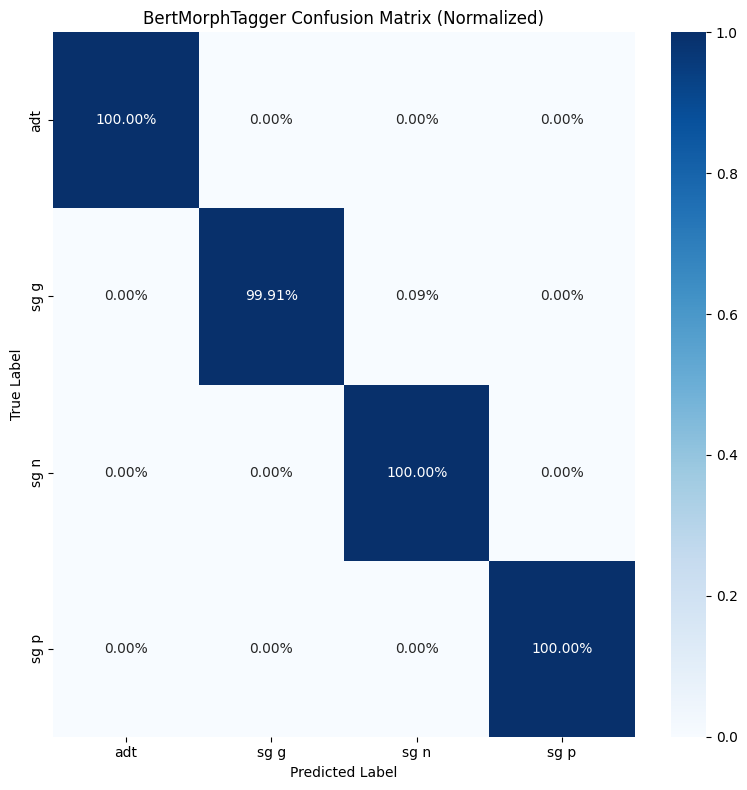

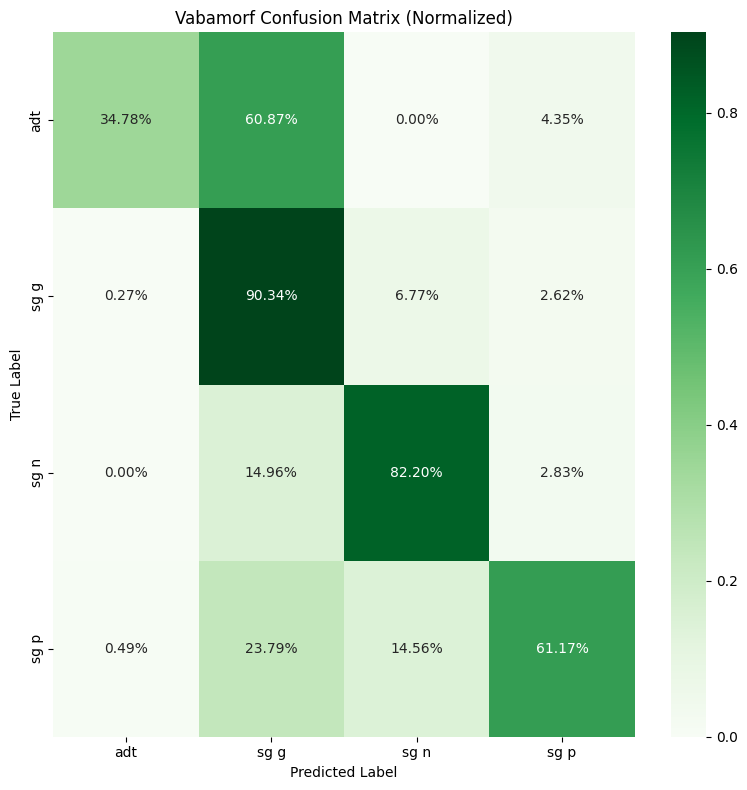

In [20]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym_small/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym_small/VabamorfCM", dpi=300)
plt.show()

In [ ]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764
        sg p       0.00      0.00      0.00         0

    accuracy                           1.00      1996
   macro avg       0.67      0.67      0.67      1996
weighted avg       1.00      1.00      1.00      1996

Vabamorf Classification Report:
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

========Inflection Type 16========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1080
    

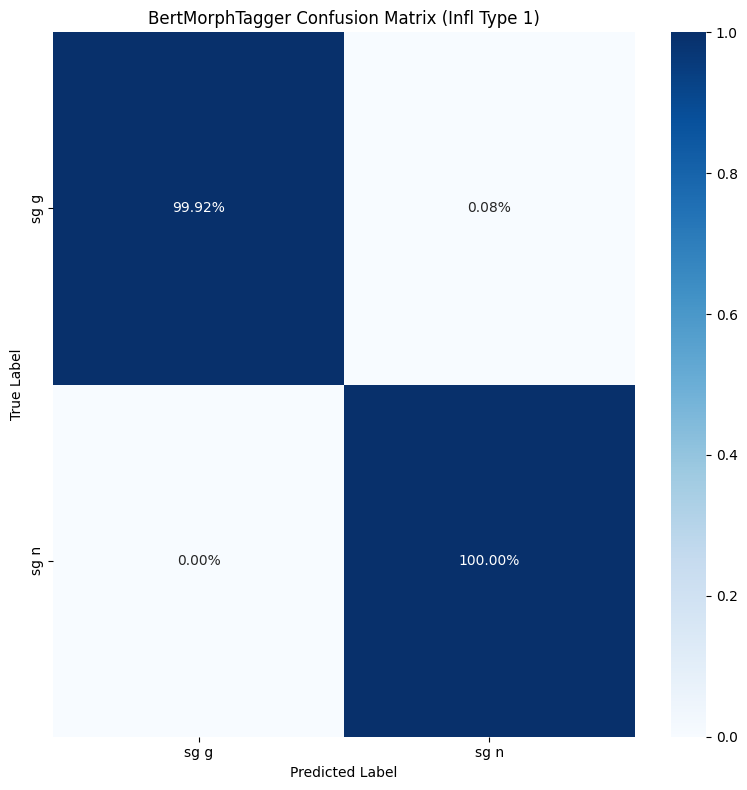

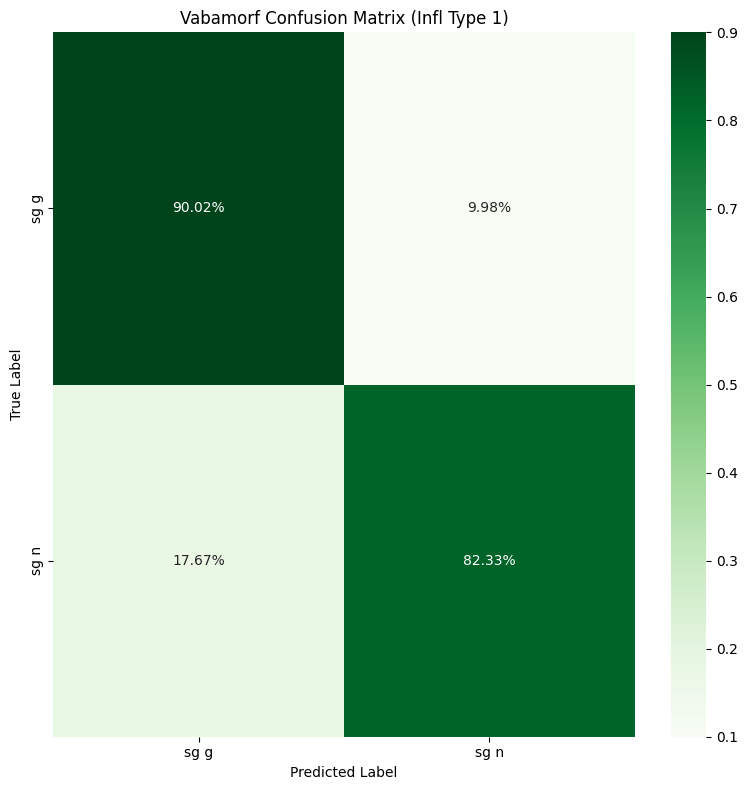

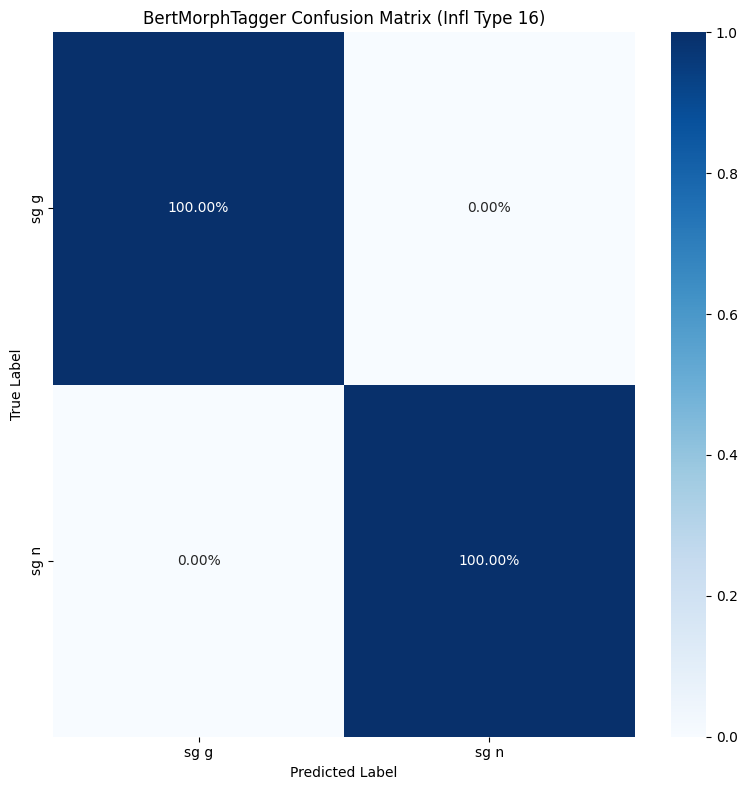

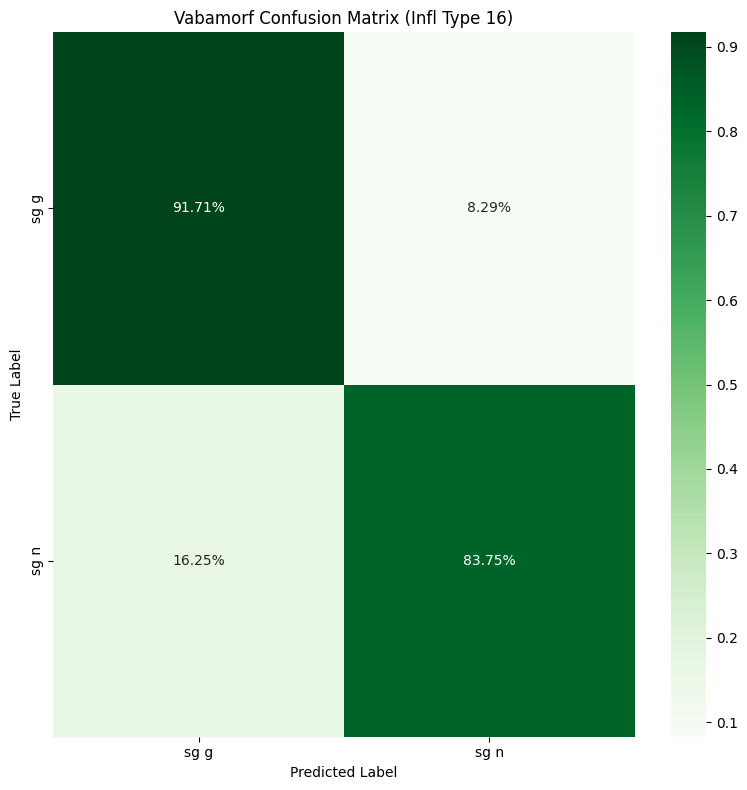

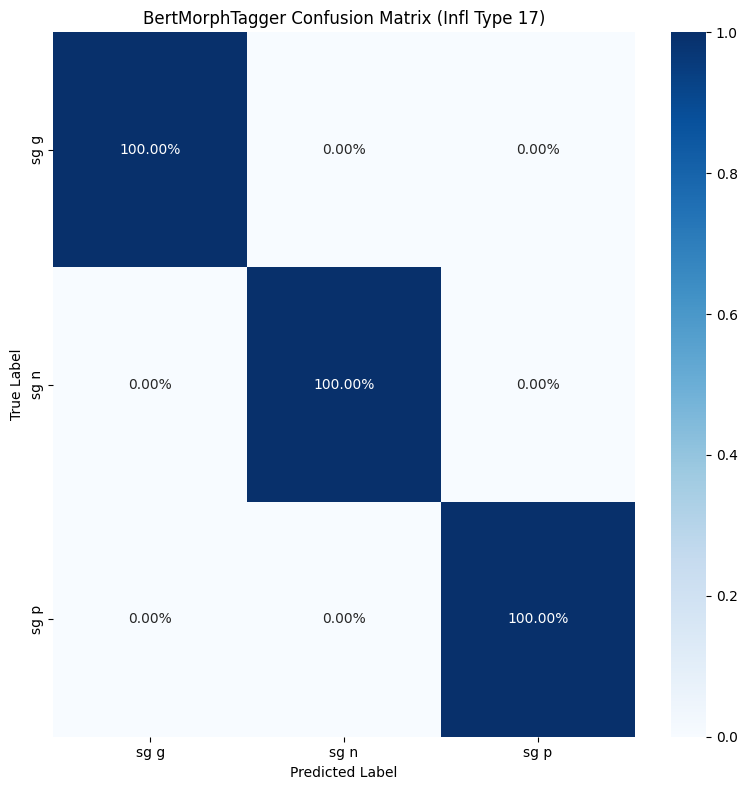

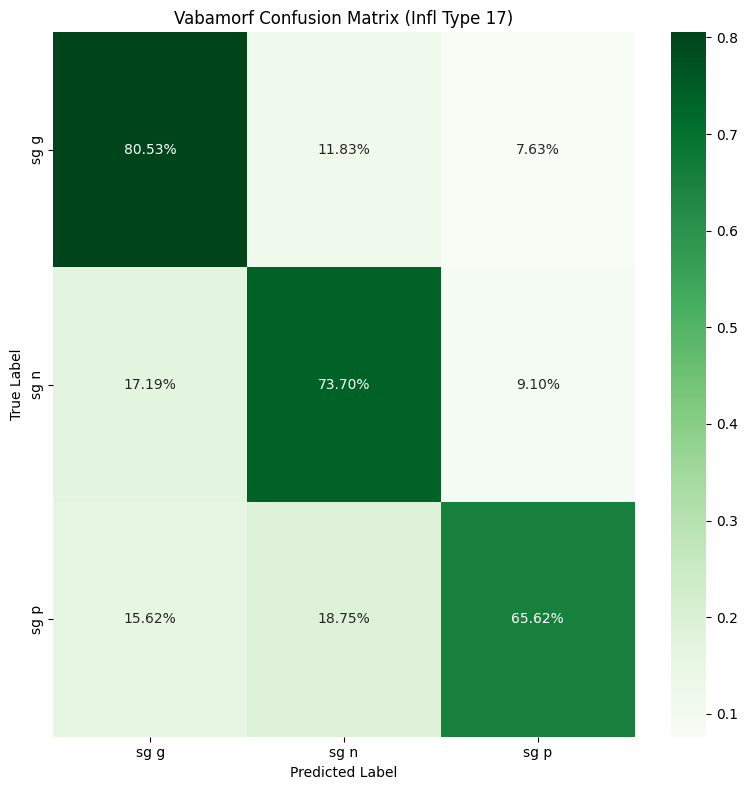

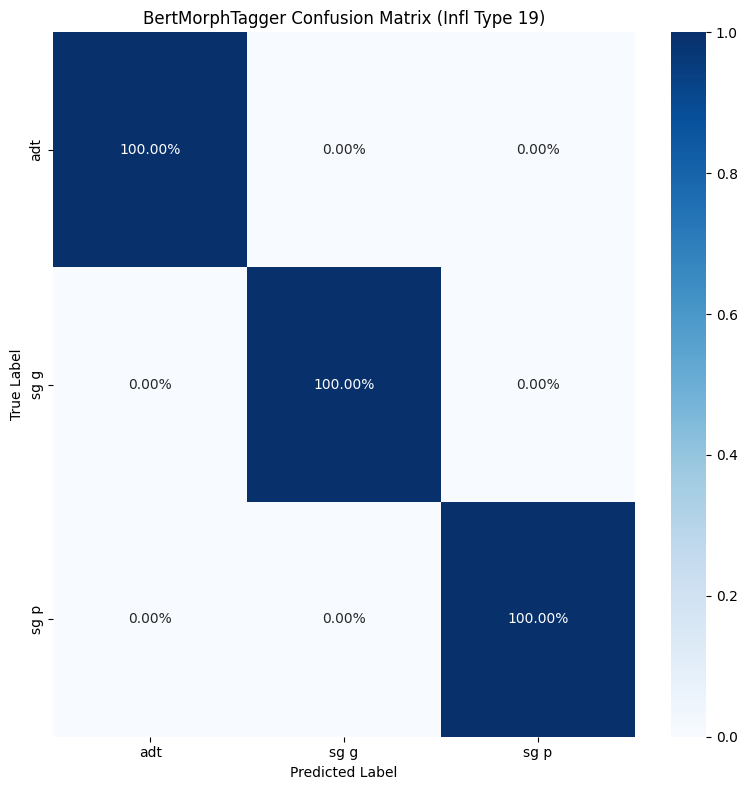

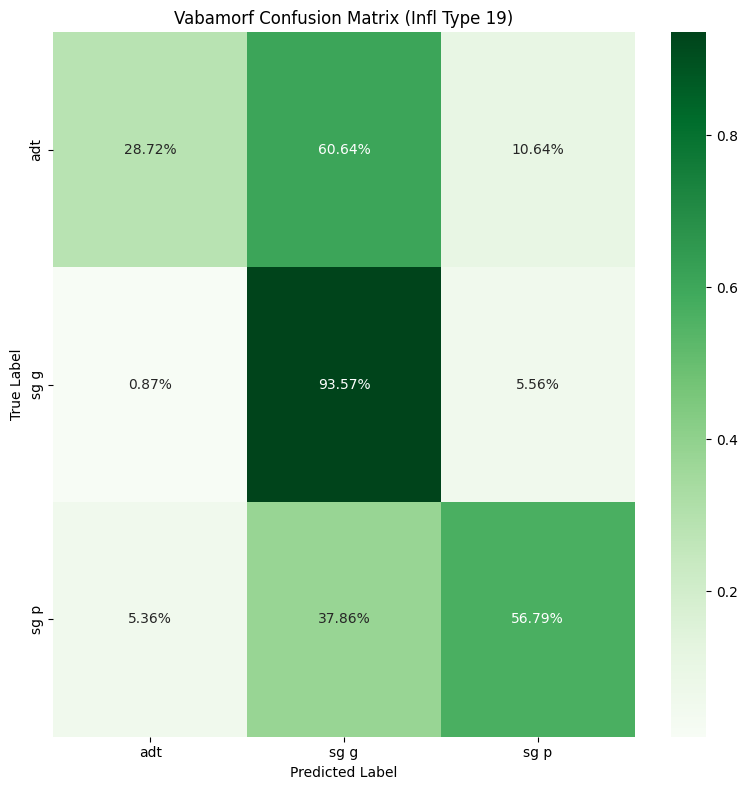

In [ ]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/homonym/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300
    )
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/homonym/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

## END
